# 01 — Arquitetura × Pré-treino

In [1]:
%matplotlib inline
import sys, json
sys.path.insert(0, '..')
import pandas as pd
from IPython.display import Image, display, Markdown
from src import config as C, data
pd.set_option('display.max_colwidth', 40)
LABELS = data.get_label_names()
print('classes:', LABELS)

classes: ['letter', 'form', 'email', 'handwritten', 'advertisement', 'scientific report', 'scientific publication', 'specification', 'file folder', 'news article', 'budget', 'invoice', 'presentation', 'questionnaire', 'resume', 'memo']


In [2]:
s=json.load(open(C.METRICS_DIR/'summary.json'))
df=pd.DataFrame(s)[['run','pretrain','accuracy','macro_f1','params_M','img_per_s','peak_vram_mb']]
df.sort_values('accuracy').reset_index(drop=True)

,run,pretrain,accuracy,macro_f1,params_M,img_per_s,peak_vram_mb
0,deit_tiny_lp,imagenet,0.576688,0.568106,5.527504,1498.610485,141.107712
1,dit_base_lp,domain,0.581063,0.573390,85.820944,188.888754,1066.312192
2,baseline_cnn,none,0.759062,0.756806,0.289520,1453.310479,1020.998144
3,resnet18,imagenet,0.798250,0.799564,11.184720,4890.104785,635.856384
4,mobilevit_s,imagenet,0.838562,0.838763,4.947888,611.853288,2436.093440
5,deit_tiny,imagenet,0.849500,0.850018,5.527504,1432.564202,707.522048
6,dit_base,domain,0.894750,0.894866,85.820944,190.516807,2175.683584
7,dit_rvlcdip_ref,domain+rvlcdip,0.930625,0.930683,85.820176,187.962110,765.895168


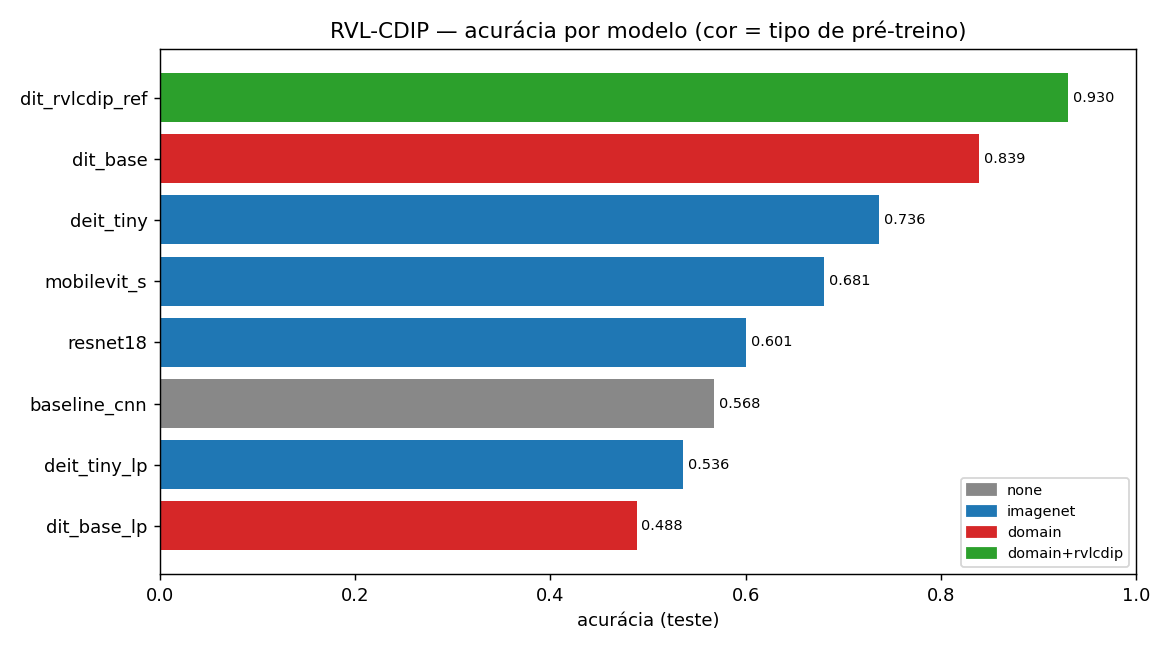

In [3]:
display(Image(filename=str(C.PLOTS_DIR/'headline_accuracy.png')))

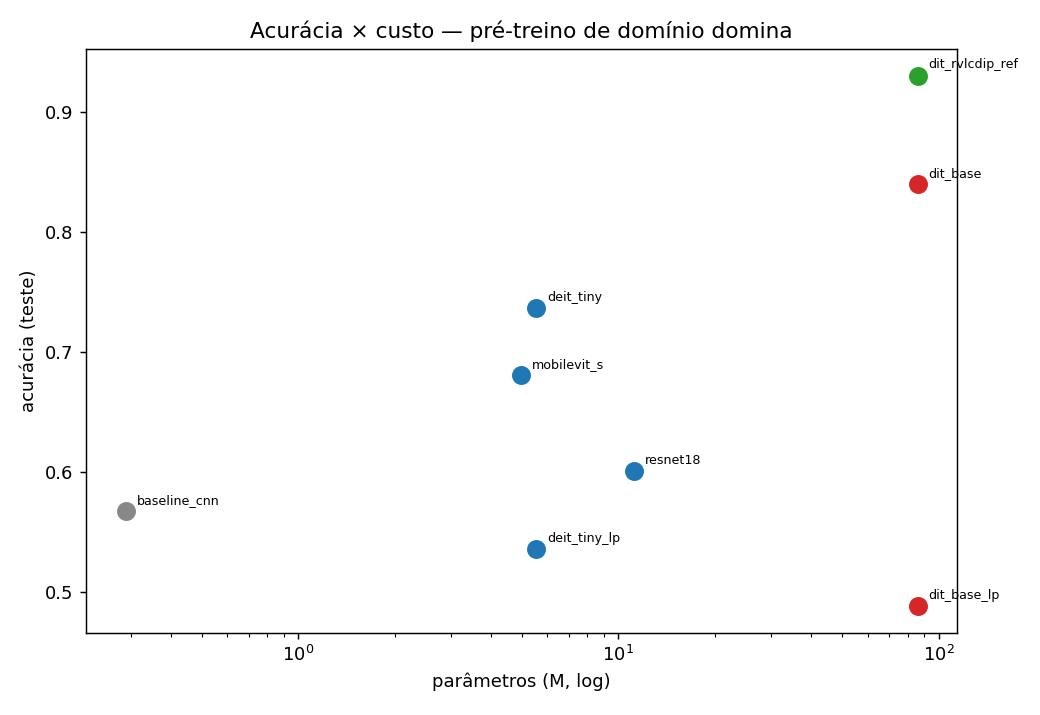

In [4]:
display(Image(filename=str(C.PLOTS_DIR/'headline_acc_vs_params.png')))

### baseline_cnn

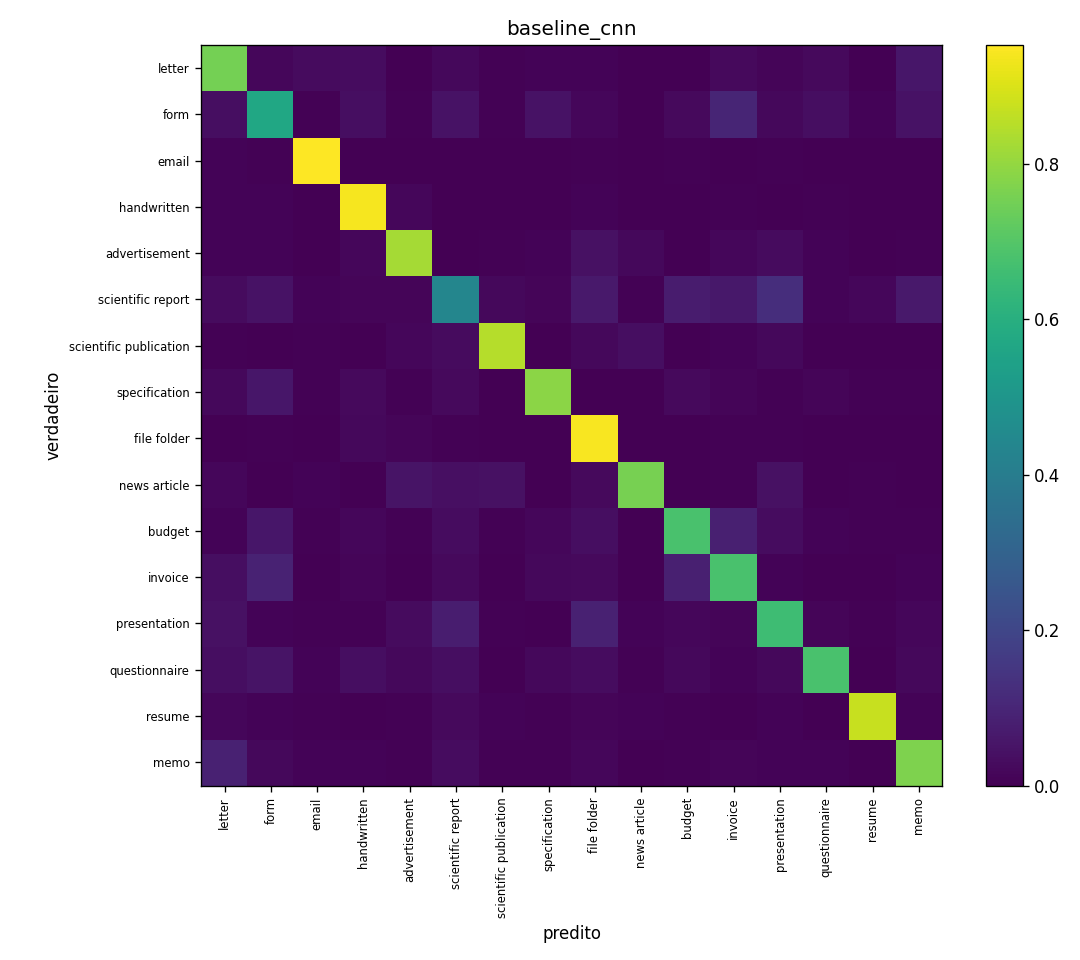

### dit_base

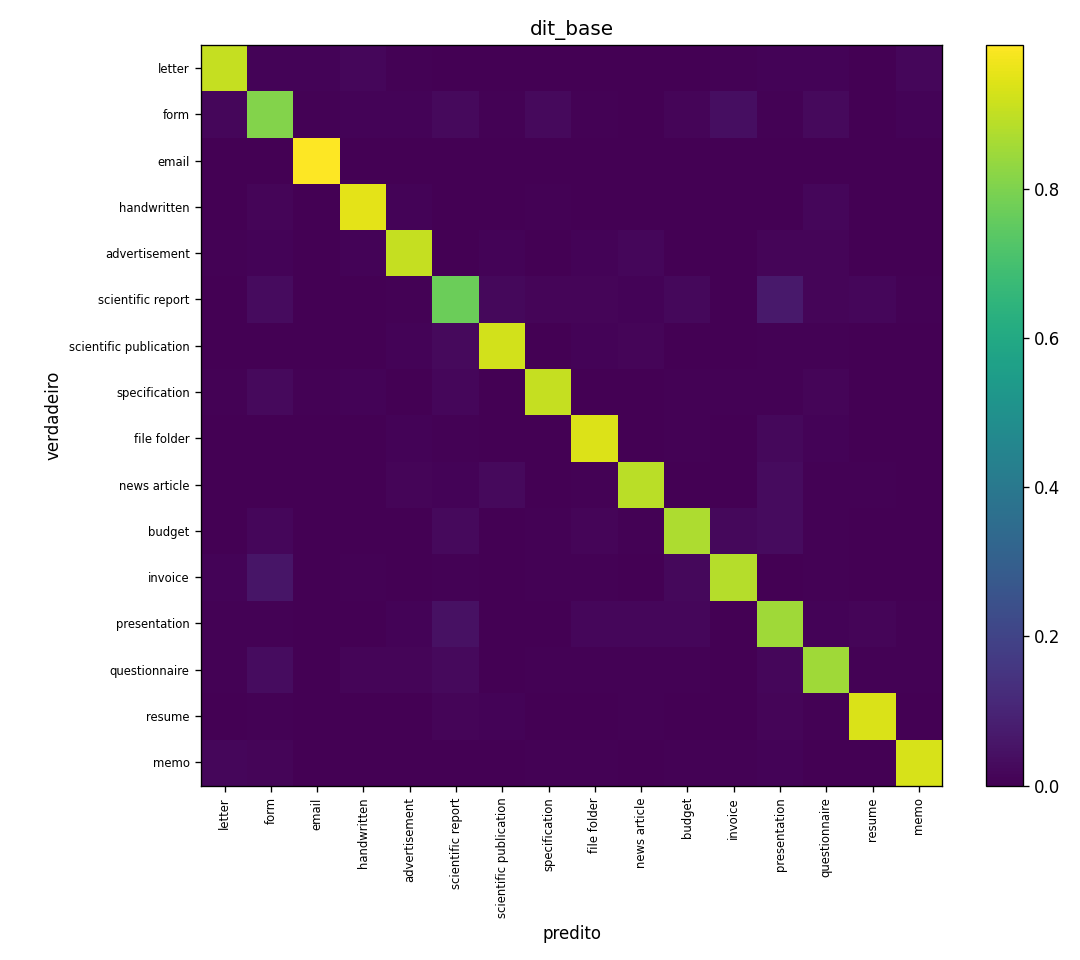

### dit_rvlcdip_ref

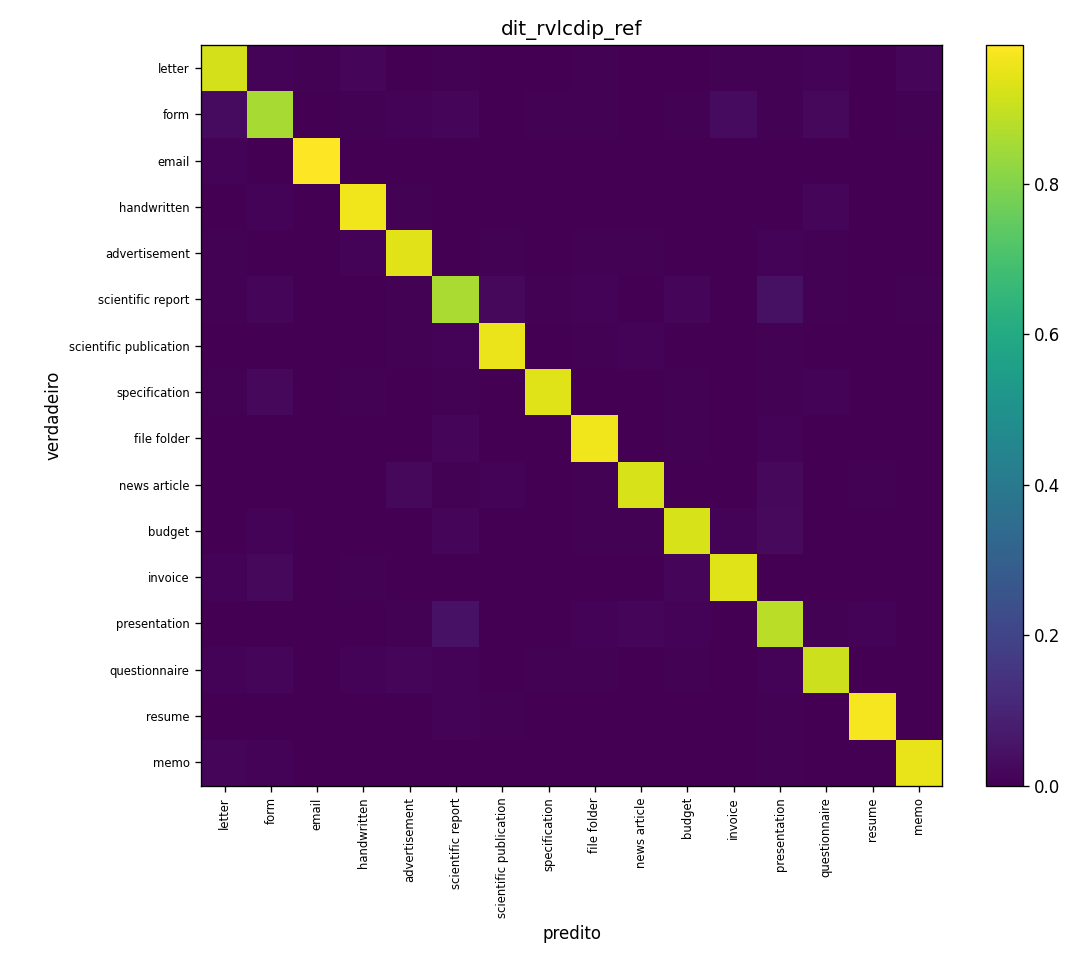

In [5]:
for r in ['baseline_cnn','dit_base','dit_rvlcdip_ref']:
    display(Markdown(f'### {r}')); display(Image(filename=str(C.PLOTS_DIR/f'{r}_confusion.png')))

In [6]:
d=json.load(open(C.METRICS_DIR/'dit_base.json'))
print('bottom-5 classes:'); display(pd.DataFrame(d['bottom5_classes'],columns=['classe','acc']))
print('top confusões:'); display(pd.DataFrame(d['top_confusions'],columns=['verdadeiro','predito','n']))

bottom-5 classes:


,classe,acc
0,scientific report,0.770
1,form,0.807
2,presentation,0.850
3,questionnaire,0.853
4,budget,0.869


top confusões:


,verdadeiro,predito,n
0,scientific report,presentation,69
1,invoice,form,55
2,presentation,scientific report,45
3,form,invoice,38
4,questionnaire,form,33
5,scientific report,form,31
6,news article,presentation,31
7,budget,presentation,30
